In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from datasets import load_dataset
from matplotlib import pyplot as plt
import random
import numpy as np
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

C:\Users\musae\Desktop\files\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Загрузка данных

In [4]:
ds = load_dataset('uoft-cs/cifar10')
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [5]:
ds["train"].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [6]:
sample = ds["train"][0]
print(type(sample))
print(sample)

<class 'dict'>
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x203430CBFD0>, 'label': 0}


In [7]:
class CifarDataset(Dataset):
    def __init__(self, data, transforms):
        self.data = data
        self.transforms = transforms
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]

        image = item['img']
        label = item['label']

        if self.transforms:
            image = self.transforms(image)
        return image, label

In [8]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [9]:
cifar10_train = CifarDataset(ds['train'], transforms=transform_train)

g = torch.Generator()
g.manual_seed(seed)

cifar10_loader_train = DataLoader(
    cifar10_train,
    batch_size=32,
    shuffle=True,
    generator=g
)

In [10]:
cifar10_test = CifarDataset(ds['test'], transforms=transform_test)

cifar10_loader_test = DataLoader(
    cifar10_test, 
    batch_size=128, 
    shuffle=False
)

# Создание модели

In [11]:
class GaussianActivationNoise(nn.Module):
    def __init__(self, sigma, relative):
        super().__init__()
        self.sigma = sigma
        self.relative = relative
    def forward(self, x):
        if not self.training or self.sigma == 0:
            return x
        
        noise = torch.randn_like(x)

        if self.relative:
            scale = x.detach().std()
            return x + self.sigma * scale * noise
        else:
            return x + self.sigma * noise

In [12]:
class Net(nn.Module):
    def __init__(self, sigma1=0, sigma2=0, sigma3=0, relative=True):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 256),
            nn.ReLU(),
            GaussianActivationNoise(sigma3, relative),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)

        return x

# Шум параметров

In [13]:
def get_omega_for_parameter(name, omega1, omega2, omega3):
    if name.startswith('block1'):
        return omega1
    elif name.startswith('block2'):
        return omega2
    else:
        return omega3

# Обучение

In [14]:
num_epochs = 20
lr = 1e-2

In [15]:
criterion = nn.CrossEntropyLoss()

In [16]:
def evaluate(model, val_loader, final=False):
    model.eval()

    correct = 0
    running_loss = 0.0
    
    correct_pred = {i: 0 for i in range(10)}
    total_pred = {i: 0 for i in range(10)}

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()

            pred = output.argmax(dim=1)

            correct += pred.eq(target.data).sum()

            for label, prediction in zip(target, pred):
                label = label.item()
                prediction = prediction.item()
                if label == prediction:
                    correct_pred[label] += 1
    
                total_pred[label] += 1
                

    accuracy = correct / len(val_loader.dataset)
    avg_loss = running_loss / len(val_loader)

    if final:
        for i in range(10):
            acc = 100 * correct_pred[i] / total_pred[i]
            print(f"Accuracy class {i} = {acc:.1f} %")
        

    return accuracy.cpu().item(), avg_loss

In [17]:
def train(net, num_epochs, omega1, omega2, omega3, relative_params=True):
    losses = []
    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(cifar10_loader_train):
            data = data.to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
    
            net_out = net(data)
            loss = criterion(net_out, target)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                for name, param in net.named_parameters():
                    if param.requires_grad:
                        omega = get_omega_for_parameter(name, omega1, omega2, omega3)
                        if omega > 0:
                            noise = torch.randn_like(param)

                            if relative_params:
                                scale = param.detach().std()
                                param.add_(omega * scale * noise)
                            else:
                                param.add_(omega * noise)
                
            running_loss += loss.item()
        if epoch == num_epochs-1: 
            val_acc, val_loss = evaluate(net, cifar10_loader_test, True)
        else:
            val_acc, val_loss = evaluate(net, cifar10_loader_test)
        losses.append(running_loss/len(cifar10_loader_train))
        print(f'epoch: {epoch+1}, train loss: {running_loss/len(cifar10_loader_train)}, val_acc: {val_acc}, val_loss: {val_loss}')

        plt.plot(losses)
        plt.xlabel("Эпоха")
        plt.ylabel("Loss");

epoch: 1, train loss: 1.8495948706692178, val_acc: 0.41849997639656067, val_loss: 1.5816583678692202
epoch: 2, train loss: 1.4106256840553943, val_acc: 0.6115999817848206, val_loss: 1.0661574436139456
epoch: 3, train loss: 1.1419101985539677, val_acc: 0.6775000095367432, val_loss: 0.9191537182542342
epoch: 4, train loss: 0.9992900577517404, val_acc: 0.7253999710083008, val_loss: 0.7901878538010996
epoch: 5, train loss: 0.9136160453465682, val_acc: 0.7386999726295471, val_loss: 0.7258564263959474
epoch: 6, train loss: 0.8623607694263726, val_acc: 0.7525999546051025, val_loss: 0.7293337575996979
epoch: 7, train loss: 0.8072161767167002, val_acc: 0.7657999992370605, val_loss: 0.6841831561885302
epoch: 8, train loss: 0.773015254690185, val_acc: 0.7770000100135803, val_loss: 0.6593447387972965
epoch: 9, train loss: 0.7428524169644254, val_acc: 0.7807999849319458, val_loss: 0.6239089094385316
epoch: 10, train loss: 0.7201278480824491, val_acc: 0.8011999726295471, val_loss: 0.5769525060925302

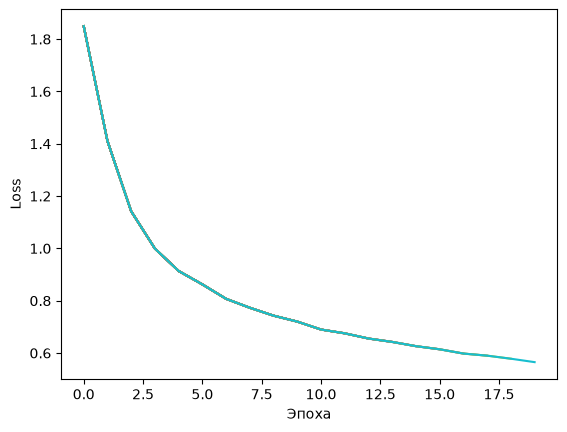

In [18]:
start = time.time()

net = Net(0, 0, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 1e-3)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8619197835849022, val_acc: 0.46469998359680176, val_loss: 1.4401214152951785
epoch: 2, train loss: 1.4362098310364413, val_acc: 0.6096999645233154, val_loss: 1.0829227815700482
epoch: 3, train loss: 1.146778121790822, val_acc: 0.6814999580383301, val_loss: 0.8927577673634396
epoch: 4, train loss: 1.0069758490500202, val_acc: 0.7076999545097351, val_loss: 0.8370359962499594
epoch: 5, train loss: 0.928723562759081, val_acc: 0.7271999716758728, val_loss: 0.7708819395379175
epoch: 6, train loss: 0.8641434139688275, val_acc: 0.7532999515533447, val_loss: 0.7056288262711296
epoch: 7, train loss: 0.8148390118959845, val_acc: 0.770799994468689, val_loss: 0.6533181731459461
epoch: 8, train loss: 0.7792022386690934, val_acc: 0.7585999965667725, val_loss: 0.7095285107063342
epoch: 9, train loss: 0.7499252029969307, val_acc: 0.7896999716758728, val_loss: 0.6268645366535911
epoch: 10, train loss: 0.7255804129254719, val_acc: 0.8015999794006348, val_loss: 0.5797163429139536
e

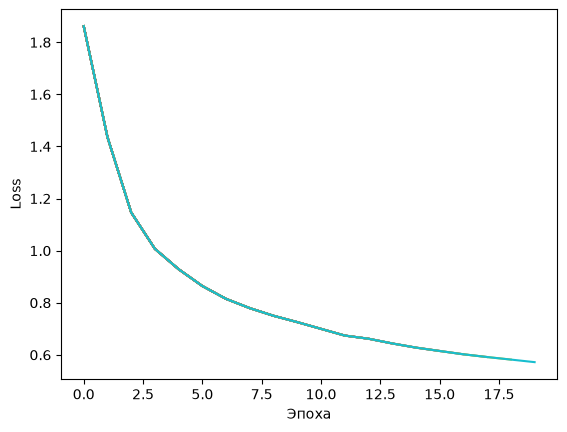

In [19]:
start = time.time()

net = Net(0, 0, 0.01)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 0, 0, 1e-3)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.854481317107676, val_acc: 0.4819999933242798, val_loss: 1.3878056339070768
epoch: 2, train loss: 1.4316791153381212, val_acc: 0.6154999732971191, val_loss: 1.0648379431495183
epoch: 3, train loss: 1.1757981909518813, val_acc: 0.6765999794006348, val_loss: 0.9185845595371874
epoch: 4, train loss: 1.0370917685963905, val_acc: 0.7166999578475952, val_loss: 0.8290800135346907
epoch: 5, train loss: 0.9396337228979121, val_acc: 0.7148999571800232, val_loss: 0.8256774318369129
epoch: 6, train loss: 0.8751902487403067, val_acc: 0.7520999908447266, val_loss: 0.7068601616575748
epoch: 7, train loss: 0.8274541152492213, val_acc: 0.7587999701499939, val_loss: 0.6975104974794991
epoch: 8, train loss: 0.7862101443784022, val_acc: 0.7615000009536743, val_loss: 0.7049457826946355
epoch: 9, train loss: 0.750552960946174, val_acc: 0.7530999779701233, val_loss: 0.7307345384283911
epoch: 10, train loss: 0.7258739142904508, val_acc: 0.793999969959259, val_loss: 0.614609763969349
epo

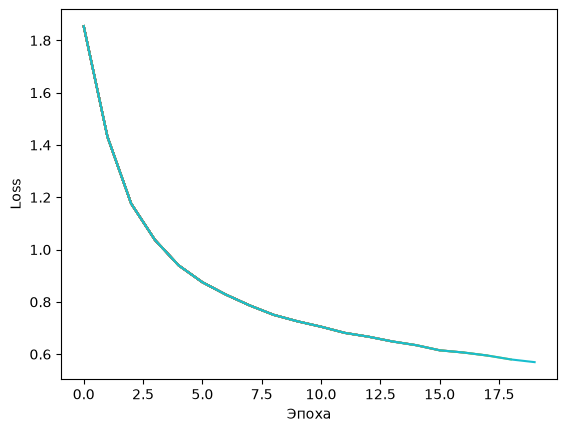

In [20]:
start = time.time()

net = Net(0.01, 0.03, 0.05)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 1e-3)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8826691244019198, val_acc: 0.4755999743938446, val_loss: 1.4076053266283832
epoch: 2, train loss: 1.4678354485250023, val_acc: 0.6049999594688416, val_loss: 1.0975905038133453
epoch: 3, train loss: 1.2040784450883066, val_acc: 0.6733999848365784, val_loss: 0.9097108840942383
epoch: 4, train loss: 1.054962841425656, val_acc: 0.7286999821662903, val_loss: 0.7733081745195992
epoch: 5, train loss: 0.9637228729666919, val_acc: 0.7457999587059021, val_loss: 0.7298433863663976
epoch: 6, train loss: 0.890714808316545, val_acc: 0.7457999587059021, val_loss: 0.7214665873141228
epoch: 7, train loss: 0.8449928840992929, val_acc: 0.7466999888420105, val_loss: 0.7375267483765566
epoch: 8, train loss: 0.809935786444944, val_acc: 0.7660999894142151, val_loss: 0.6677397930923896
epoch: 9, train loss: 0.765937254643181, val_acc: 0.7858999967575073, val_loss: 0.6350083275686337
epoch: 10, train loss: 0.7425182268013957, val_acc: 0.7901999950408936, val_loss: 0.6187498377093786
epo

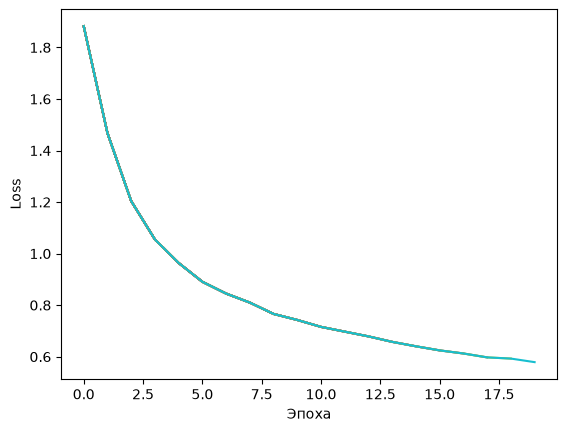

In [21]:
start = time.time()

net = Net(0.03, 0.03, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 1e-4, 1e-4, 1e-4)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.912447018876567, val_acc: 0.4332999885082245, val_loss: 1.476630133918569
epoch: 2, train loss: 1.4667263611417052, val_acc: 0.589199960231781, val_loss: 1.16860863679572
epoch: 3, train loss: 1.17715000480852, val_acc: 0.6868999600410461, val_loss: 0.8891326958620096
epoch: 4, train loss: 1.0325320756976908, val_acc: 0.6998999714851379, val_loss: 0.8589746340920653
epoch: 5, train loss: 0.9397732866969691, val_acc: 0.7288999557495117, val_loss: 0.7762633611129809
epoch: 6, train loss: 0.8807798372158544, val_acc: 0.7238999605178833, val_loss: 0.8143599055990388
epoch: 7, train loss: 0.8312802668458288, val_acc: 0.7806999683380127, val_loss: 0.642710333383536
epoch: 8, train loss: 0.7920122161288332, val_acc: 0.765999972820282, val_loss: 0.6812251821348939
epoch: 9, train loss: 0.7561579520551348, val_acc: 0.7777000069618225, val_loss: 0.6573267978957936
epoch: 10, train loss: 0.7272365180273813, val_acc: 0.7990999817848206, val_loss: 0.5907281788089608
epoch: 1

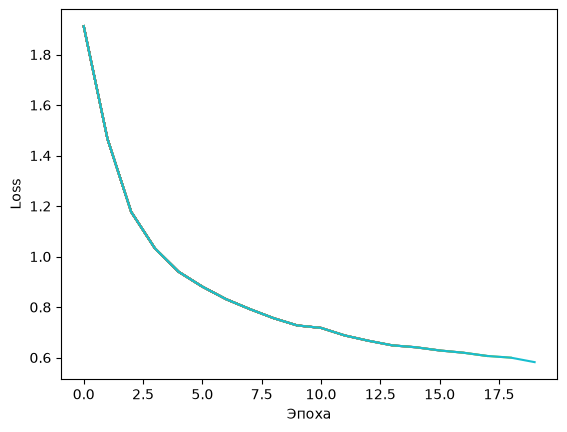

In [22]:
start = time.time()

net = Net(0.03, 0.03, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 1e-3, 1e-3, 1e-3)

print('Время обучения', time.time() - start)